In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose

import torch
import numpy as np
import random
import os
from torch.utils.data import DataLoader
def set_seed(seed):
    random.seed(seed)
    np.random.default_rng(seed)
    torch.manual_seed(seed)

    # Ensure that CUDA operations are deterministic if using GPU
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True
        # # slower but more reproducibility
        # torch.backends.cudnn.benchmark = False
set_seed(42)

In [3]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import transforms

from ilipy import Session
from ilipy.database import DistanceCorrelation
from ilipy import ClipTypes, OdometerTicks, OdometerTickRange, ViewDistance
from ilipy.sensors import ArmAngleLookup

from tqdm import tqdm
from typing import Dict

from rnd.utils.modeling import get_model
from rnd.utils.transform import resize_to_224
from rnd.utils.dataset_multi_channel_v1_1 import NumpyImageFolder

In [4]:
class PreprocessingModel(nn.Module):
    def __init__(self, model, transform):
        super().__init__()
        self.model = model
        self.transform = transform

    def forward(self, input_np_image):
        # Apply transform to NumPy image (expects single image, not batch)
        x = self.transform(input_np_image)
        x = x.unsqueeze(0)  # Add batch dimension
        return self.model(x)

In [5]:
def load_model(model_name, dense_units, dropout, model_path):
    """
    Load a PyTorch model with weights and return it along with the transform.

    Returns:
        model (torch.nn.Module): The loaded model ready for inference.
        transform (callable): The image preprocessing pipeline.
        weights: The weight metadata used for normalization.
    """
    model, weights = get_model(model_name, dense_units, dropout)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    return model, weights

In [6]:
#model, weights = load_model("resnet", 128, 0.5, "models/dent_models/resnet_v1_13_32.pth")
model,weights = load_model("resnet", 128, 0.5, "models/dent_models/resnet_v1_3_16.pth")

transform = transforms.Compose(
    [
        transforms.Lambda(resize_to_224), # should output (C, H, W)
        transforms.Lambda(lambda x: torch.from_numpy(x).float()),
        transforms.Normalize(
            mean=weights.transforms().mean, std=weights.transforms().std
        ),
    ]
)

In [7]:
val_dir = "./data/fhr4/final_data_v1.1/training"
val_ds = NumpyImageFolder(root_dir=val_dir, transform=transform, debug=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
# model.eval()
# model.to(device)
# all_preds = []
# all_labels = []
# pred_list = []
# vd_list = []
# total_mislabeled = 0
# with torch.inference_mode():
#     for batch_idx, (inputs, labels, names) in enumerate(val_loader2):
#         # labels expected shape [B] with 0/1
        
#             inputs = inputs.to(device)
#             labels = labels.float().to(device)
#             labels=torch.ones(inputs.size(0)).to(device)

#             raw_outputs = model(inputs)
#             for i in range(inputs.size(0)):

#                 if "fhr4" in names[i]:
#                     #plot inputs
#                     plt.imshow(inputs[i,2,:].cpu().numpy())
#                     plt.show()
#                     print(names[i])
#                     all_val_probs = torch.sigmoid(raw_outputs[i])
#                     print(all_val_probs)
#                     if torch.any(all_val_probs >= 0.5):
#                         preds = raw_outputs.argmax(axis=1)
#                     else:
#                         preds = torch.zeros_like(raw_outputs.argmax(axis=1))
#                         total_mislabeled += 1
#                     print(preds[i].item())
#                     print(all_val_probs)
#                     print(all_val_probs >= 0.9)
#                     print(all_val_probs >= 0.5)
#                     pred_list.append(preds[i].item())
#                     vd_list.append(int(names[i].split("_")[-1].replace(".npy","")[2:]))


d0157437623_track_[6]_hroll_-20_noise.npy with tensor([5.9314e-03, 1.2260e-04, 1.7100e-06, 9.9981e-06, 2.1734e-06, 2.3188e-04,
        4.1975e-02, 1.2833e-04, 1.2961e-05, 8.8951e-05, 8.6321e-06, 9.6659e-06,
        5.9216e-05, 2.7780e-05, 4.8859e-05, 4.8664e-05, 6.5293e-06, 7.2882e-06,
        5.2946e-04, 3.2136e-02], device='cuda:0')
d0169162597_track_[5]_hroll_0_orig.npy with tensor([2.2266e-06, 2.3263e-08, 2.6598e-07, 3.7545e-08, 8.8247e-07, 9.2503e-02,
        2.6489e-06, 1.1810e-08, 1.5064e-06, 2.0304e-08, 3.3072e-09, 2.1859e-08,
        3.4712e-07, 2.8919e-07, 8.1981e-07, 1.1934e-06, 8.9291e-08, 2.0309e-06,
        2.6415e-05, 1.7976e-06], device='cuda:0')
d0157437623_track_[6]_hroll_0_scaled.npy with tensor([1.1933e-02, 2.4272e-04, 2.1257e-06, 3.4421e-05, 1.4468e-06, 4.4561e-04,
        3.8291e-01, 1.6042e-04, 1.2461e-05, 3.2158e-04, 6.8885e-06, 1.2183e-05,
        1.5890e-04, 1.7605e-05, 1.9100e-05, 2.6865e-05, 2.2114e-06, 7.1878e-06,
        4.5535e-04, 1.0195e-02], device='cu

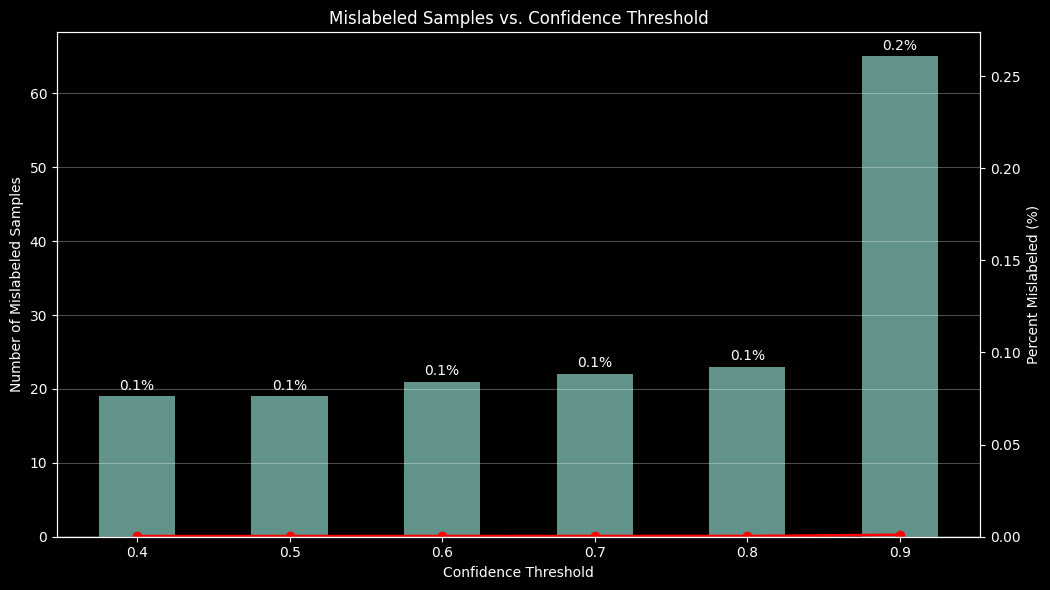

In [9]:
# Evaluate model across different thresholds
model.eval()
model.to(device)

thresholds = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
results = []

for threshold in thresholds:
    total_mislabeled = 0
    total_samples = 0
    
    with torch.inference_mode():
        for batch_idx, (inputs, labels, names) in enumerate(val_loader):
            inputs = inputs.to(device)
            total_samples += inputs.size(0)
            
            # Forward pass
            raw_outputs = model(inputs)
            all_probs = torch.sigmoid(raw_outputs)
            
            # Count samples where no class exceeds the threshold (mislabeled)
            for i in range(inputs.size(0)):
                if torch.all(labels[i] == 0):
                    continue  # Skip known negatives
                if not torch.any(all_probs[i] >= threshold):
                    total_mislabeled += 1
                    print(names[i], "with", all_probs[i])

    # Store results for this threshold
    results.append({
        'threshold': threshold,
        'mislabeled': total_mislabeled,
        'total': total_samples,
        'mislabeled_percent': (total_mislabeled / total_samples) * 100
    })
    print(f"Threshold {threshold:.1f}: {total_mislabeled}/{total_samples} mislabeled ({total_mislabeled/total_samples:.1%})")

# Plotting
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Extract data for plotting
thresholds = [r['threshold'] for r in results]
mislabeled_counts = [r['mislabeled'] for r in results]
mislabeled_percent = [r['mislabeled_percent'] for r in results]

# Create bar plot
bars = plt.bar(thresholds, mislabeled_counts, width=0.05, alpha=0.7)

# Add percentage labels on top of bars
for bar, percent in zip(bars, mislabeled_percent):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{percent:.1f}%', ha='center', va='bottom')

# Add a line showing percentage
plt.plot(thresholds, mislabeled_percent, 'r-o', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

# Add labels and title
plt.xlabel('Confidence Threshold')
plt.ylabel('Number of Mislabeled Samples')
plt.title('Mislabeled Samples vs. Confidence Threshold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Add second y-axis for percentage
ax2 = plt.gca().twinx()
ax2.set_ylabel('Percent Mislabeled (%)')
ax2.plot(thresholds, mislabeled_percent, 'r-', alpha=0)  # Invisible, just for scale
ax2.set_ylim(0, max(mislabeled_percent) * 1.1)

plt.show()